In [ ]:
import pandas as pd

In [ ]:
data = pd.read_csv('/content/lasso_batchy.csv')
data = data.drop(columns=['Unnamed: 0'])
data.head()

,Gene,C1,C2,C3,C4,C5,C6,C7,C8,C9,...,D29,D30,D31,D32,D33,D34,D35,D36,D37,D38
0,ACSM1,10.914760,11.135962,8.891566,8.074361,9.557551,10.132283,10.019072,8.925043,11.817970,...,7.659350,6.397556,6.226404,5.630004,7.850567,6.779979,5.882256,10.540738,7.262209,7.532407
1,ADORA2B,5.110096,5.805840,4.750283,5.620902,5.434974,5.514895,4.450006,6.229374,4.439311,...,6.540154,5.116456,5.080135,7.398721,6.450155,3.579958,5.938070,6.692122,6.385460,5.950856
2,AGPAT1,3.896571,5.078981,4.389263,5.705530,5.356997,5.326282,5.437688,4.551041,2.857657,...,5.213546,5.277771,6.954467,7.280251,6.796259,8.176044,6.867025,6.206010,7.782533,6.400674
3,BTBD16,6.838794,6.487988,6.991046,5.690952,6.632153,6.535228,6.927929,4.979223,7.734810,...,4.949167,4.854093,2.889749,5.578432,5.914876,6.037106,4.780228,3.544489,3.142159,4.833111
4,CCDC178,6.137514,6.115845,5.544265,6.502288,8.371001,6.477630,8.866079,5.789687,5.656918,...,4.466889,4.313042,3.611286,4.570975,5.151161,3.790559,4.200692,4.406053,4.664216,4.987756


In [ ]:
data = data.T

In [ ]:
y = data.index.to_series().str[0]
y = y.map({'C': 0, 'D': 1})
y = y.drop("Gene")
y
data.reset_index(inplace = True)

data.drop("index", axis = 1, inplace = True)
X = data
# Make first row the header
X.columns = X.iloc[0]

# Remove that first row
X = X.drop(X.index[0])

# Convert to numeric
X = X.apply(pd.to_numeric)
X


,ACSM1,ADORA2B,AGPAT1,BTBD16,CCDC178,CD207,CLRN1,CMA1,CSMD1,DDT,...,SFRP4,SIK1,SLC2A14,SORCS3,STC1,TBC1D3L,TNFRSF17,TYR,USP17L2,WDR46
1,10.914760,5.110096,3.896571,6.838794,6.137514,6.335811,6.009826,4.404689,8.698855,3.646425,...,12.193521,5.697186,2.974660,5.043856,6.742106,4.391362,5.723762,7.119836,8.620417,4.919325
2,11.135962,5.805840,5.078981,6.487988,6.115845,4.977656,5.474359,5.221860,7.239703,3.538015,...,10.480460,5.022233,4.247290,4.857951,4.822149,4.373500,6.082677,6.200747,8.470901,4.877400
3,8.891566,4.750283,4.389263,6.991046,5.544265,5.854893,6.827014,5.897843,10.042353,4.492789,...,11.926017,4.880500,3.793164,3.881190,7.631016,4.571990,5.470134,5.550446,8.192874,3.748831
4,8.074361,5.620902,5.705530,5.690952,6.502288,5.733583,4.652300,5.626731,8.580342,3.771152,...,13.494115,6.238118,2.781264,5.574711,8.175455,4.230194,6.473276,5.648787,7.811523,3.628753
5,9.557551,5.434974,5.356997,6.632153,8.371001,6.031605,5.919477,4.324369,7.790120,3.969257,...,11.788102,6.211392,3.135282,3.558551,6.543452,4.989646,6.105548,6.003599,7.399032,4.015435
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67,6.779979,3.579958,8.176044,6.037106,3.790559,5.955599,8.112708,3.799325,6.478235,3.457107,...,10.890283,6.371103,5.944549,7.714985,9.056544,2.989828,5.051926,4.590912,7.227312,7.534752
68,5.882256,5.938070,6.867025,4.780228,4.200692,7.120193,7.008641,5.275480,6.822246,3.674302,...,11.551356,4.638456,5.725493,7.030303,9.135109,4.425790,4.721240,4.575075,6.103253,6.043637
69,10.540738,6.692122,6.206010,3.544489,4.406053,8.428116,6.119198,3.879046,8.752773,3.514716,...,9.344778,6.806512,4.146754,4.050462,10.532865,5.542763,4.414228,4.553074,5.016077,5.212523
70,7.262209,6.385460,7.782533,3.142159,4.664216,6.850532,4.242906,4.150065,6.151992,5.022798,...,10.195798,9.094513,3.853907,4.198532,11.917931,5.721694,5.591699,2.992995,2.595225,4.808556


In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold
import pandas as pd
import joblib
import os
from datetime import datetime

# ================== CONFIG ==================
BASE_DIR = "/content/drive/MyDrive/DTC/10_10"
os.makedirs(BASE_DIR, exist_ok=True)

# Define model
model = DecisionTreeClassifier(random_state=42)

# Parameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy'],
    'max_features': [None, 'sqrt', 'log2']
}

# Scoring dictionary
scoring_dict = {
    'accuracy': 'accuracy',
    'roc_auc': 'roc_auc',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'f1_macro': 'f1_macro',
    'f1_weighted': 'f1_weighted',
    'precision_weighted': 'precision_weighted',
    'recall_weighted': 'recall_weighted',
    'average_precision': 'average_precision',
    'neg_log_loss': 'neg_log_loss'
}

# ================== REPEATED STRATIFIED K-FOLD ==================
rskf = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=10,
    random_state=42
)

# Grid Search
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=scoring_dict,
    refit='accuracy',
    cv=rskf,
    verbose=1,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X, y)

# ================== RESULTS ==================
print("="*70)
print("🏆 BEST PARAMETERS")
print("="*70)
print(grid_search.best_params_)
print(f"\nBest Accuracy : {grid_search.best_score_:.4f}")

results = pd.DataFrame(grid_search.cv_results_)
timestamp = datetime.now().strftime("%Y%m%d_%H%M")

# ================== METRIC COLUMNS ==================
param_cols = ['param_max_depth', 'param_min_samples_split',
              'param_min_samples_leaf', 'param_criterion', 'param_max_features']

metric_cols = []
for metric in scoring_dict.keys():
    metric_cols.append(f'mean_test_{metric}')
    metric_cols.append(f'std_test_{metric}')

all_cols = param_cols + metric_cols

# ================== SAVE FULL SUMMARY CSV ==================
summary_path = f"{BASE_DIR}/gridsearch_dt_FULL_{timestamp}.csv"
results[all_cols].to_csv(summary_path, index=False)
print(f"\n📊 Full results saved to '{summary_path}'")

# ================== SAVE ONE CSV PER PARAMETER COMBO ==================
print(f"\n📁 Saving individual files per parameter combination in {BASE_DIR}...")

for idx, row in results.iterrows():
    depth = row['param_max_depth']
    split = row['param_min_samples_split']
    leaf = row['param_min_samples_leaf']
    criterion = row['param_criterion']
    features = row['param_max_features']

    # Sanitize for filename
    depth_str = str(depth) if depth is not None else 'none'
    features_str = str(features) if features is not None else 'none'

    filename = (
        f"{BASE_DIR}/combo"
        f"__depth{depth_str}"
        f"__split{split}"
        f"__leaf{leaf}"
        f"__crit{criterion}"
        f"__feat{features_str}"
        f".csv"
    )

    # Build row data
    row_data = {
        'max_depth': [depth],
        'min_samples_split': [split],
        'min_samples_leaf': [leaf],
        'criterion': [criterion],
        'max_features': [features],
        'rank_accuracy': [row['rank_test_accuracy']],
    }

    for metric in scoring_dict.keys():
        row_data[f'mean_{metric}'] = [round(row[f'mean_test_{metric}'], 4)]
        row_data[f'std_{metric}'] = [round(row[f'std_test_{metric}'], 4)]

    pd.DataFrame(row_data).to_csv(filename, index=False)

print(f"✅ {len(results)} individual combo files saved in '{BASE_DIR}'")

# ================== TOP 5 SUMMARY ==================
print("\n=== Top 5 Models (sorted by accuracy) ===")
top5 = results[all_cols].sort_values('mean_test_accuracy', ascending=False).head(5).round(4)
print(top5.to_string(index=False))

# ================== SAVE BEST MODEL ==================
best_model = grid_search.best_estimator_
model_path = f"{BASE_DIR}/decision_tree_best_model_{timestamp}.pkl"
joblib.dump(best_model, model_path)
print(f"\n✅ Best model saved as '{model_path}'")
print("\n🎉 Training with RepeatedStratifiedKFold completed!")

Fitting 100 folds for each of 480 candidates, totalling 48000 fits
🏆 BEST PARAMETERS
{'criterion': 'gini', 'max_depth': 3, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2}

Best Accuracy : 0.9520

📊 Full results saved to '/content/drive/MyDrive/DTC/10_10/gridsearch_dt_FULL_20260529_0914.csv'

📁 Saving individual files per parameter combination in /content/drive/MyDrive/DTC/10_10...
✅ 480 individual combo files saved in '/content/drive/MyDrive/DTC/10_10'

=== Top 5 Models (sorted by accuracy) ===
param_max_depth  param_min_samples_split  param_min_samples_leaf param_criterion param_max_features  mean_test_accuracy  std_test_accuracy  mean_test_roc_auc  std_test_roc_auc  mean_test_f1  std_test_f1  mean_test_precision  std_test_precision  mean_test_recall  std_test_recall  mean_test_f1_macro  std_test_f1_macro  mean_test_f1_weighted  std_test_f1_weighted  mean_test_precision_weighted  std_test_precision_weighted  mean_test_recall_weighted  std_test_recall_weighted  m

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold
import pandas as pd
import joblib
import os
from datetime import datetime

# ================== CONFIG ==================
BASE_DIR = "/content/drive/MyDrive/DTC/10_5"
os.makedirs(BASE_DIR, exist_ok=True)

# Define model
model = DecisionTreeClassifier(random_state=42)

# Parameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy'],
    'max_features': [None, 'sqrt', 'log2']
}

# Scoring dictionary
scoring_dict = {
    'accuracy': 'accuracy',
    'roc_auc': 'roc_auc',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'f1_macro': 'f1_macro',
    'f1_weighted': 'f1_weighted',
    'precision_weighted': 'precision_weighted',
    'recall_weighted': 'recall_weighted',
    'average_precision': 'average_precision',
    'neg_log_loss': 'neg_log_loss'
}

# ================== REPEATED STRATIFIED K-FOLD ==================
rskf = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=5,
    random_state=42
)

# Grid Search
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=scoring_dict,
    refit='accuracy',
    cv=rskf,
    verbose=1,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X, y)

# ================== RESULTS ==================
print("="*70)
print("🏆 BEST PARAMETERS")
print("="*70)
print(grid_search.best_params_)
print(f"\nBest Accuracy : {grid_search.best_score_:.4f}")

results = pd.DataFrame(grid_search.cv_results_)
timestamp = datetime.now().strftime("%Y%m%d_%H%M")

# ================== METRIC COLUMNS ==================
param_cols = ['param_max_depth', 'param_min_samples_split',
              'param_min_samples_leaf', 'param_criterion', 'param_max_features']

metric_cols = []
for metric in scoring_dict.keys():
    metric_cols.append(f'mean_test_{metric}')
    metric_cols.append(f'std_test_{metric}')

all_cols = param_cols + metric_cols

# ================== SAVE FULL SUMMARY CSV ==================
summary_path = f"{BASE_DIR}/gridsearch_dt_FULL_{timestamp}.csv"
results[all_cols].to_csv(summary_path, index=False)
print(f"\n📊 Full results saved to '{summary_path}'")

# ================== SAVE ONE CSV PER PARAMETER COMBO ==================
print(f"\n📁 Saving individual files per parameter combination in {BASE_DIR}...")

for idx, row in results.iterrows():
    depth = row['param_max_depth']
    split = row['param_min_samples_split']
    leaf = row['param_min_samples_leaf']
    criterion = row['param_criterion']
    features = row['param_max_features']

    # Sanitize for filename
    depth_str = str(depth) if depth is not None else 'none'
    features_str = str(features) if features is not None else 'none'

    filename = (
        f"{BASE_DIR}/combo"
        f"__depth{depth_str}"
        f"__split{split}"
        f"__leaf{leaf}"
        f"__crit{criterion}"
        f"__feat{features_str}"
        f".csv"
    )

    # Build row data
    row_data = {
        'max_depth': [depth],
        'min_samples_split': [split],
        'min_samples_leaf': [leaf],
        'criterion': [criterion],
        'max_features': [features],
        'rank_accuracy': [row['rank_test_accuracy']],
    }

    for metric in scoring_dict.keys():
        row_data[f'mean_{metric}'] = [round(row[f'mean_test_{metric}'], 4)]
        row_data[f'std_{metric}'] = [round(row[f'std_test_{metric}'], 4)]

    pd.DataFrame(row_data).to_csv(filename, index=False)

print(f"✅ {len(results)} individual combo files saved in '{BASE_DIR}'")

# ================== TOP 5 SUMMARY ==================
print("\n=== Top 5 Models (sorted by accuracy) ===")
top5 = results[all_cols].sort_values('mean_test_accuracy', ascending=False).head(5).round(4)
print(top5.to_string(index=False))

# ================== SAVE BEST MODEL ==================
best_model = grid_search.best_estimator_
model_path = f"{BASE_DIR}/decision_tree_best_model_{timestamp}.pkl"
joblib.dump(best_model, model_path)
print(f"\n✅ Best model saved as '{model_path}'")
print("\n🎉 Training with RepeatedStratifiedKFold completed!")

Fitting 50 folds for each of 480 candidates, totalling 24000 fits
🏆 BEST PARAMETERS
{'criterion': 'gini', 'max_depth': 3, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2}

Best Accuracy : 0.9639

📊 Full results saved to '/content/drive/MyDrive/DTC/10_5/gridsearch_dt_FULL_20260529_0935.csv'

📁 Saving individual files per parameter combination in /content/drive/MyDrive/DTC/10_5...
✅ 480 individual combo files saved in '/content/drive/MyDrive/DTC/10_5'

=== Top 5 Models (sorted by accuracy) ===
param_max_depth  param_min_samples_split  param_min_samples_leaf param_criterion param_max_features  mean_test_accuracy  std_test_accuracy  mean_test_roc_auc  std_test_roc_auc  mean_test_f1  std_test_f1  mean_test_precision  std_test_precision  mean_test_recall  std_test_recall  mean_test_f1_macro  std_test_f1_macro  mean_test_f1_weighted  std_test_f1_weighted  mean_test_precision_weighted  std_test_precision_weighted  mean_test_recall_weighted  std_test_recall_weighted  mean_

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold
import pandas as pd
import joblib
import os
from datetime import datetime

# ================== CONFIG ==================
BASE_DIR = "/content/drive/MyDrive/DTC/10_2"
os.makedirs(BASE_DIR, exist_ok=True)

# Define model
model = DecisionTreeClassifier(random_state=42)

# Parameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy'],
    'max_features': [None, 'sqrt', 'log2']
}

# Scoring dictionary
scoring_dict = {
    'accuracy': 'accuracy',
    'roc_auc': 'roc_auc',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'f1_macro': 'f1_macro',
    'f1_weighted': 'f1_weighted',
    'precision_weighted': 'precision_weighted',
    'recall_weighted': 'recall_weighted',
    'average_precision': 'average_precision',
    'neg_log_loss': 'neg_log_loss'
}

# ================== REPEATED STRATIFIED K-FOLD ==================
rskf = RepeatedStratifiedKFold(
    n_splits=10,
    n_repeats=2,
    random_state=42
)

# Grid Search
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=scoring_dict,
    refit='accuracy',
    cv=rskf,
    verbose=1,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X, y)

# ================== RESULTS ==================
print("="*70)
print("🏆 BEST PARAMETERS")
print("="*70)
print(grid_search.best_params_)
print(f"\nBest Accuracy : {grid_search.best_score_:.4f}")

results = pd.DataFrame(grid_search.cv_results_)
timestamp = datetime.now().strftime("%Y%m%d_%H%M")

# ================== METRIC COLUMNS ==================
param_cols = ['param_max_depth', 'param_min_samples_split',
              'param_min_samples_leaf', 'param_criterion', 'param_max_features']

metric_cols = []
for metric in scoring_dict.keys():
    metric_cols.append(f'mean_test_{metric}')
    metric_cols.append(f'std_test_{metric}')

all_cols = param_cols + metric_cols

# ================== SAVE FULL SUMMARY CSV ==================
summary_path = f"{BASE_DIR}/gridsearch_dt_FULL_{timestamp}.csv"
results[all_cols].to_csv(summary_path, index=False)
print(f"\n📊 Full results saved to '{summary_path}'")

# ================== SAVE ONE CSV PER PARAMETER COMBO ==================
print(f"\n📁 Saving individual files per parameter combination in {BASE_DIR}...")

for idx, row in results.iterrows():
    depth = row['param_max_depth']
    split = row['param_min_samples_split']
    leaf = row['param_min_samples_leaf']
    criterion = row['param_criterion']
    features = row['param_max_features']

    # Sanitize for filename
    depth_str = str(depth) if depth is not None else 'none'
    features_str = str(features) if features is not None else 'none'

    filename = (
        f"{BASE_DIR}/combo"
        f"__depth{depth_str}"
        f"__split{split}"
        f"__leaf{leaf}"
        f"__crit{criterion}"
        f"__feat{features_str}"
        f".csv"
    )

    # Build row data
    row_data = {
        'max_depth': [depth],
        'min_samples_split': [split],
        'min_samples_leaf': [leaf],
        'criterion': [criterion],
        'max_features': [features],
        'rank_accuracy': [row['rank_test_accuracy']],
    }

    for metric in scoring_dict.keys():
        row_data[f'mean_{metric}'] = [round(row[f'mean_test_{metric}'], 4)]
        row_data[f'std_{metric}'] = [round(row[f'std_test_{metric}'], 4)]

    pd.DataFrame(row_data).to_csv(filename, index=False)

print(f"✅ {len(results)} individual combo files saved in '{BASE_DIR}'")

# ================== TOP 5 SUMMARY ==================
print("\n=== Top 5 Models (sorted by accuracy) ===")
top5 = results[all_cols].sort_values('mean_test_accuracy', ascending=False).head(5).round(4)
print(top5.to_string(index=False))

# ================== SAVE BEST MODEL ==================
best_model = grid_search.best_estimator_
model_path = f"{BASE_DIR}/decision_tree_best_model_{timestamp}.pkl"
joblib.dump(best_model, model_path)
print(f"\n✅ Best model saved as '{model_path}'")
print("\n🎉 Training with RepeatedStratifiedKFold completed!")

Fitting 20 folds for each of 480 candidates, totalling 9600 fits
🏆 BEST PARAMETERS
{'criterion': 'gini', 'max_depth': 3, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2}

Best Accuracy : 0.9652

📊 Full results saved to '/content/drive/MyDrive/DTC/10_2/gridsearch_dt_FULL_20260529_1213.csv'

📁 Saving individual files per parameter combination in /content/drive/MyDrive/DTC/10_2...
✅ 480 individual combo files saved in '/content/drive/MyDrive/DTC/10_2'

=== Top 5 Models (sorted by accuracy) ===
param_max_depth  param_min_samples_split  param_min_samples_leaf param_criterion param_max_features  mean_test_accuracy  std_test_accuracy  mean_test_roc_auc  std_test_roc_auc  mean_test_f1  std_test_f1  mean_test_precision  std_test_precision  mean_test_recall  std_test_recall  mean_test_f1_macro  std_test_f1_macro  mean_test_f1_weighted  std_test_f1_weighted  mean_test_precision_weighted  std_test_precision_weighted  mean_test_recall_weighted  std_test_recall_weighted  mean_t

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import pandas as pd
import joblib
import os
from datetime import datetime

# ================== CONFIG ==================
BASE_DIR = "/content/drive/MyDrive/DTC/only10"
os.makedirs(BASE_DIR, exist_ok=True)

# Define model
model = DecisionTreeClassifier(random_state=42)

# Parameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy'],
    'max_features': [None, 'sqrt', 'log2']
}

# Scoring dictionary
scoring_dict = {
    'accuracy': 'accuracy',
    'roc_auc': 'roc_auc',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'f1_macro': 'f1_macro',
    'f1_weighted': 'f1_weighted',
    'precision_weighted': 'precision_weighted',
    'recall_weighted': 'recall_weighted',
    'average_precision': 'average_precision',
    'neg_log_loss': 'neg_log_loss'
}

# ================== STRATIFIED K-FOLD ==================
skf = StratifiedKFold(
    n_splits=10,
    shuffle=True,
    random_state=42
)

# Grid Search
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=scoring_dict,
    refit='accuracy',
    cv=skf,
    verbose=1,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X, y)

# ================== RESULTS ==================
print("="*70)
print("🏆 BEST PARAMETERS")
print("="*70)
print(grid_search.best_params_)
print(f"\nBest Accuracy : {grid_search.best_score_:.4f}")

results = pd.DataFrame(grid_search.cv_results_)
timestamp = datetime.now().strftime("%Y%m%d_%H%M")

# ================== METRIC COLUMNS ==================
param_cols = ['param_max_depth', 'param_min_samples_split',
              'param_min_samples_leaf', 'param_criterion', 'param_max_features']

metric_cols = []
for metric in scoring_dict.keys():
    metric_cols.append(f'mean_test_{metric}')
    metric_cols.append(f'std_test_{metric}')

all_cols = param_cols + metric_cols

# ================== SAVE FULL SUMMARY CSV ==================
summary_path = f"{BASE_DIR}/gridsearch_dt_FULL_{timestamp}.csv"
results[all_cols].to_csv(summary_path, index=False)
print(f"\n📊 Full results saved to '{summary_path}'")

# ================== SAVE ONE CSV PER PARAMETER COMBO ==================
print(f"\n📁 Saving individual files per parameter combination in {BASE_DIR}...")

for idx, row in results.iterrows():
    depth = row['param_max_depth']
    split = row['param_min_samples_split']
    leaf = row['param_min_samples_leaf']
    criterion = row['param_criterion']
    features = row['param_max_features']

    # Sanitize for filename
    depth_str = str(depth) if depth is not None else 'none'
    features_str = str(features) if features is not None else 'none'

    filename = (
        f"{BASE_DIR}/combo"
        f"__depth{depth_str}"
        f"__split{split}"
        f"__leaf{leaf}"
        f"__crit{criterion}"
        f"__feat{features_str}"
        f".csv"
    )

    # Build row data
    row_data = {
        'max_depth': [depth],
        'min_samples_split': [split],
        'min_samples_leaf': [leaf],
        'criterion': [criterion],
        'max_features': [features],
        'rank_accuracy': [row['rank_test_accuracy']],
    }

    for metric in scoring_dict.keys():
        row_data[f'mean_{metric}'] = [round(row[f'mean_test_{metric}'], 4)]
        row_data[f'std_{metric}'] = [round(row[f'std_test_{metric}'], 4)]

    pd.DataFrame(row_data).to_csv(filename, index=False)

print(f"✅ {len(results)} individual combo files saved in '{BASE_DIR}'")

# ================== TOP 5 SUMMARY ==================
print("\n=== Top 5 Models (sorted by accuracy) ===")
top5 = results[all_cols].sort_values('mean_test_accuracy', ascending=False).head(5).round(4)
print(top5.to_string(index=False))

# ================== SAVE BEST MODEL ==================
best_model = grid_search.best_estimator_
model_path = f"{BASE_DIR}/decision_tree_best_model_{timestamp}.pkl"
joblib.dump(best_model, model_path)
print(f"\n✅ Best model saved as '{model_path}'")
print("\n🎉 Training with StratifiedKFold completed!")

Fitting 10 folds for each of 480 candidates, totalling 4800 fits
🏆 BEST PARAMETERS
{'criterion': 'gini', 'max_depth': 3, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2}

Best Accuracy : 0.9589

📊 Full results saved to '/content/drive/MyDrive/DTC/only10/gridsearch_dt_FULL_20260529_0951.csv'

📁 Saving individual files per parameter combination in /content/drive/MyDrive/DTC/only10...
✅ 480 individual combo files saved in '/content/drive/MyDrive/DTC/only10'

=== Top 5 Models (sorted by accuracy) ===
param_max_depth  param_min_samples_split  param_min_samples_leaf param_criterion param_max_features  mean_test_accuracy  std_test_accuracy  mean_test_roc_auc  std_test_roc_auc  mean_test_f1  std_test_f1  mean_test_precision  std_test_precision  mean_test_recall  std_test_recall  mean_test_f1_macro  std_test_f1_macro  mean_test_f1_weighted  std_test_f1_weighted  mean_test_precision_weighted  std_test_precision_weighted  mean_test_recall_weighted  std_test_recall_weighted  

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV, StratifiedKFold
import pandas as pd
import joblib
import os
from datetime import datetime

# ================== CONFIG ==================
BASE_DIR = "/content/drive/MyDrive/DTC/only5"
os.makedirs(BASE_DIR, exist_ok=True)

# Define model
model = DecisionTreeClassifier(random_state=42)

# Parameter grid
param_grid = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 4, 8],
    'criterion': ['gini', 'entropy'],
    'max_features': [None, 'sqrt', 'log2']
}

# Scoring dictionary
scoring_dict = {
    'accuracy': 'accuracy',
    'roc_auc': 'roc_auc',
    'f1': 'f1',
    'precision': 'precision',
    'recall': 'recall',
    'f1_macro': 'f1_macro',
    'f1_weighted': 'f1_weighted',
    'precision_weighted': 'precision_weighted',
    'recall_weighted': 'recall_weighted',
    'average_precision': 'average_precision',
    'neg_log_loss': 'neg_log_loss'
}

# ================== STRATIFIED K-FOLD ==================
skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

# Grid Search
grid_search = GridSearchCV(
    estimator=model,
    param_grid=param_grid,
    scoring=scoring_dict,
    refit='accuracy',
    cv=skf,
    verbose=1,
    n_jobs=-1,
    return_train_score=True
)

grid_search.fit(X, y)

# ================== RESULTS ==================
print("="*70)
print("🏆 BEST PARAMETERS")
print("="*70)
print(grid_search.best_params_)
print(f"\nBest Accuracy : {grid_search.best_score_:.4f}")

results = pd.DataFrame(grid_search.cv_results_)
timestamp = datetime.now().strftime("%Y%m%d_%H%M")

# ================== METRIC COLUMNS ==================
param_cols = ['param_max_depth', 'param_min_samples_split',
              'param_min_samples_leaf', 'param_criterion', 'param_max_features']

metric_cols = []
for metric in scoring_dict.keys():
    metric_cols.append(f'mean_test_{metric}')
    metric_cols.append(f'std_test_{metric}')

all_cols = param_cols + metric_cols

# ================== SAVE FULL SUMMARY CSV ==================
summary_path = f"{BASE_DIR}/gridsearch_dt_FULL_{timestamp}.csv"
results[all_cols].to_csv(summary_path, index=False)
print(f"\n📊 Full results saved to '{summary_path}'")

# ================== SAVE ONE CSV PER PARAMETER COMBO ==================
print(f"\n📁 Saving individual files per parameter combination in {BASE_DIR}...")

for idx, row in results.iterrows():
    depth = row['param_max_depth']
    split = row['param_min_samples_split']
    leaf = row['param_min_samples_leaf']
    criterion = row['param_criterion']
    features = row['param_max_features']

    # Sanitize for filename
    depth_str = str(depth) if depth is not None else 'none'
    features_str = str(features) if features is not None else 'none'

    filename = (
        f"{BASE_DIR}/combo"
        f"__depth{depth_str}"
        f"__split{split}"
        f"__leaf{leaf}"
        f"__crit{criterion}"
        f"__feat{features_str}"
        f".csv"
    )

    # Build row data
    row_data = {
        'max_depth': [depth],
        'min_samples_split': [split],
        'min_samples_leaf': [leaf],
        'criterion': [criterion],
        'max_features': [features],
        'rank_accuracy': [row['rank_test_accuracy']],
    }

    for metric in scoring_dict.keys():
        row_data[f'mean_{metric}'] = [round(row[f'mean_test_{metric}'], 4)]
        row_data[f'std_{metric}'] = [round(row[f'std_test_{metric}'], 4)]

    pd.DataFrame(row_data).to_csv(filename, index=False)

print(f"✅ {len(results)} individual combo files saved in '{BASE_DIR}'")

# ================== TOP 5 SUMMARY ==================
print("\n=== Top 5 Models (sorted by accuracy) ===")
top5 = results[all_cols].sort_values('mean_test_accuracy', ascending=False).head(5).round(4)
print(top5.to_string(index=False))

# ================== SAVE BEST MODEL ==================
best_model = grid_search.best_estimator_
model_path = f"{BASE_DIR}/decision_tree_best_model_{timestamp}.pkl"
joblib.dump(best_model, model_path)
print(f"\n✅ Best model saved as '{model_path}'")
print("\n🎉 Training with StratifiedKFold completed!")

Fitting 5 folds for each of 480 candidates, totalling 2400 fits
🏆 BEST PARAMETERS
{'criterion': 'gini', 'max_depth': 3, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 2}

Best Accuracy : 0.9581

📊 Full results saved to '/content/drive/MyDrive/DTC/only5/gridsearch_dt_FULL_20260529_0953.csv'

📁 Saving individual files per parameter combination in /content/drive/MyDrive/DTC/only5...
✅ 480 individual combo files saved in '/content/drive/MyDrive/DTC/only5'

=== Top 5 Models (sorted by accuracy) ===
param_max_depth  param_min_samples_split  param_min_samples_leaf param_criterion param_max_features  mean_test_accuracy  std_test_accuracy  mean_test_roc_auc  std_test_roc_auc  mean_test_f1  std_test_f1  mean_test_precision  std_test_precision  mean_test_recall  std_test_recall  mean_test_f1_macro  std_test_f1_macro  mean_test_f1_weighted  std_test_f1_weighted  mean_test_precision_weighted  std_test_precision_weighted  mean_test_recall_weighted  std_test_recall_weighted  mean

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from datetime import datetime
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    classification_report, confusion_matrix
)
from datetime import datetime

from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, matthews_corrcoef
)
from matplotlib.colors import ListedColormap
from sklearn.model_selection import (
    RepeatedStratifiedKFold,
    GridSearchCV,
    cross_val_predict,
)
from sklearn.model_selection import GridSearchCV


In [ ]:
import pickle
best_model = joblib.load('/content/drive/MyDrive/DTC/10_2/decision_tree_best_model_20260529_0944.pkl')

# Open the file in read-binary mode



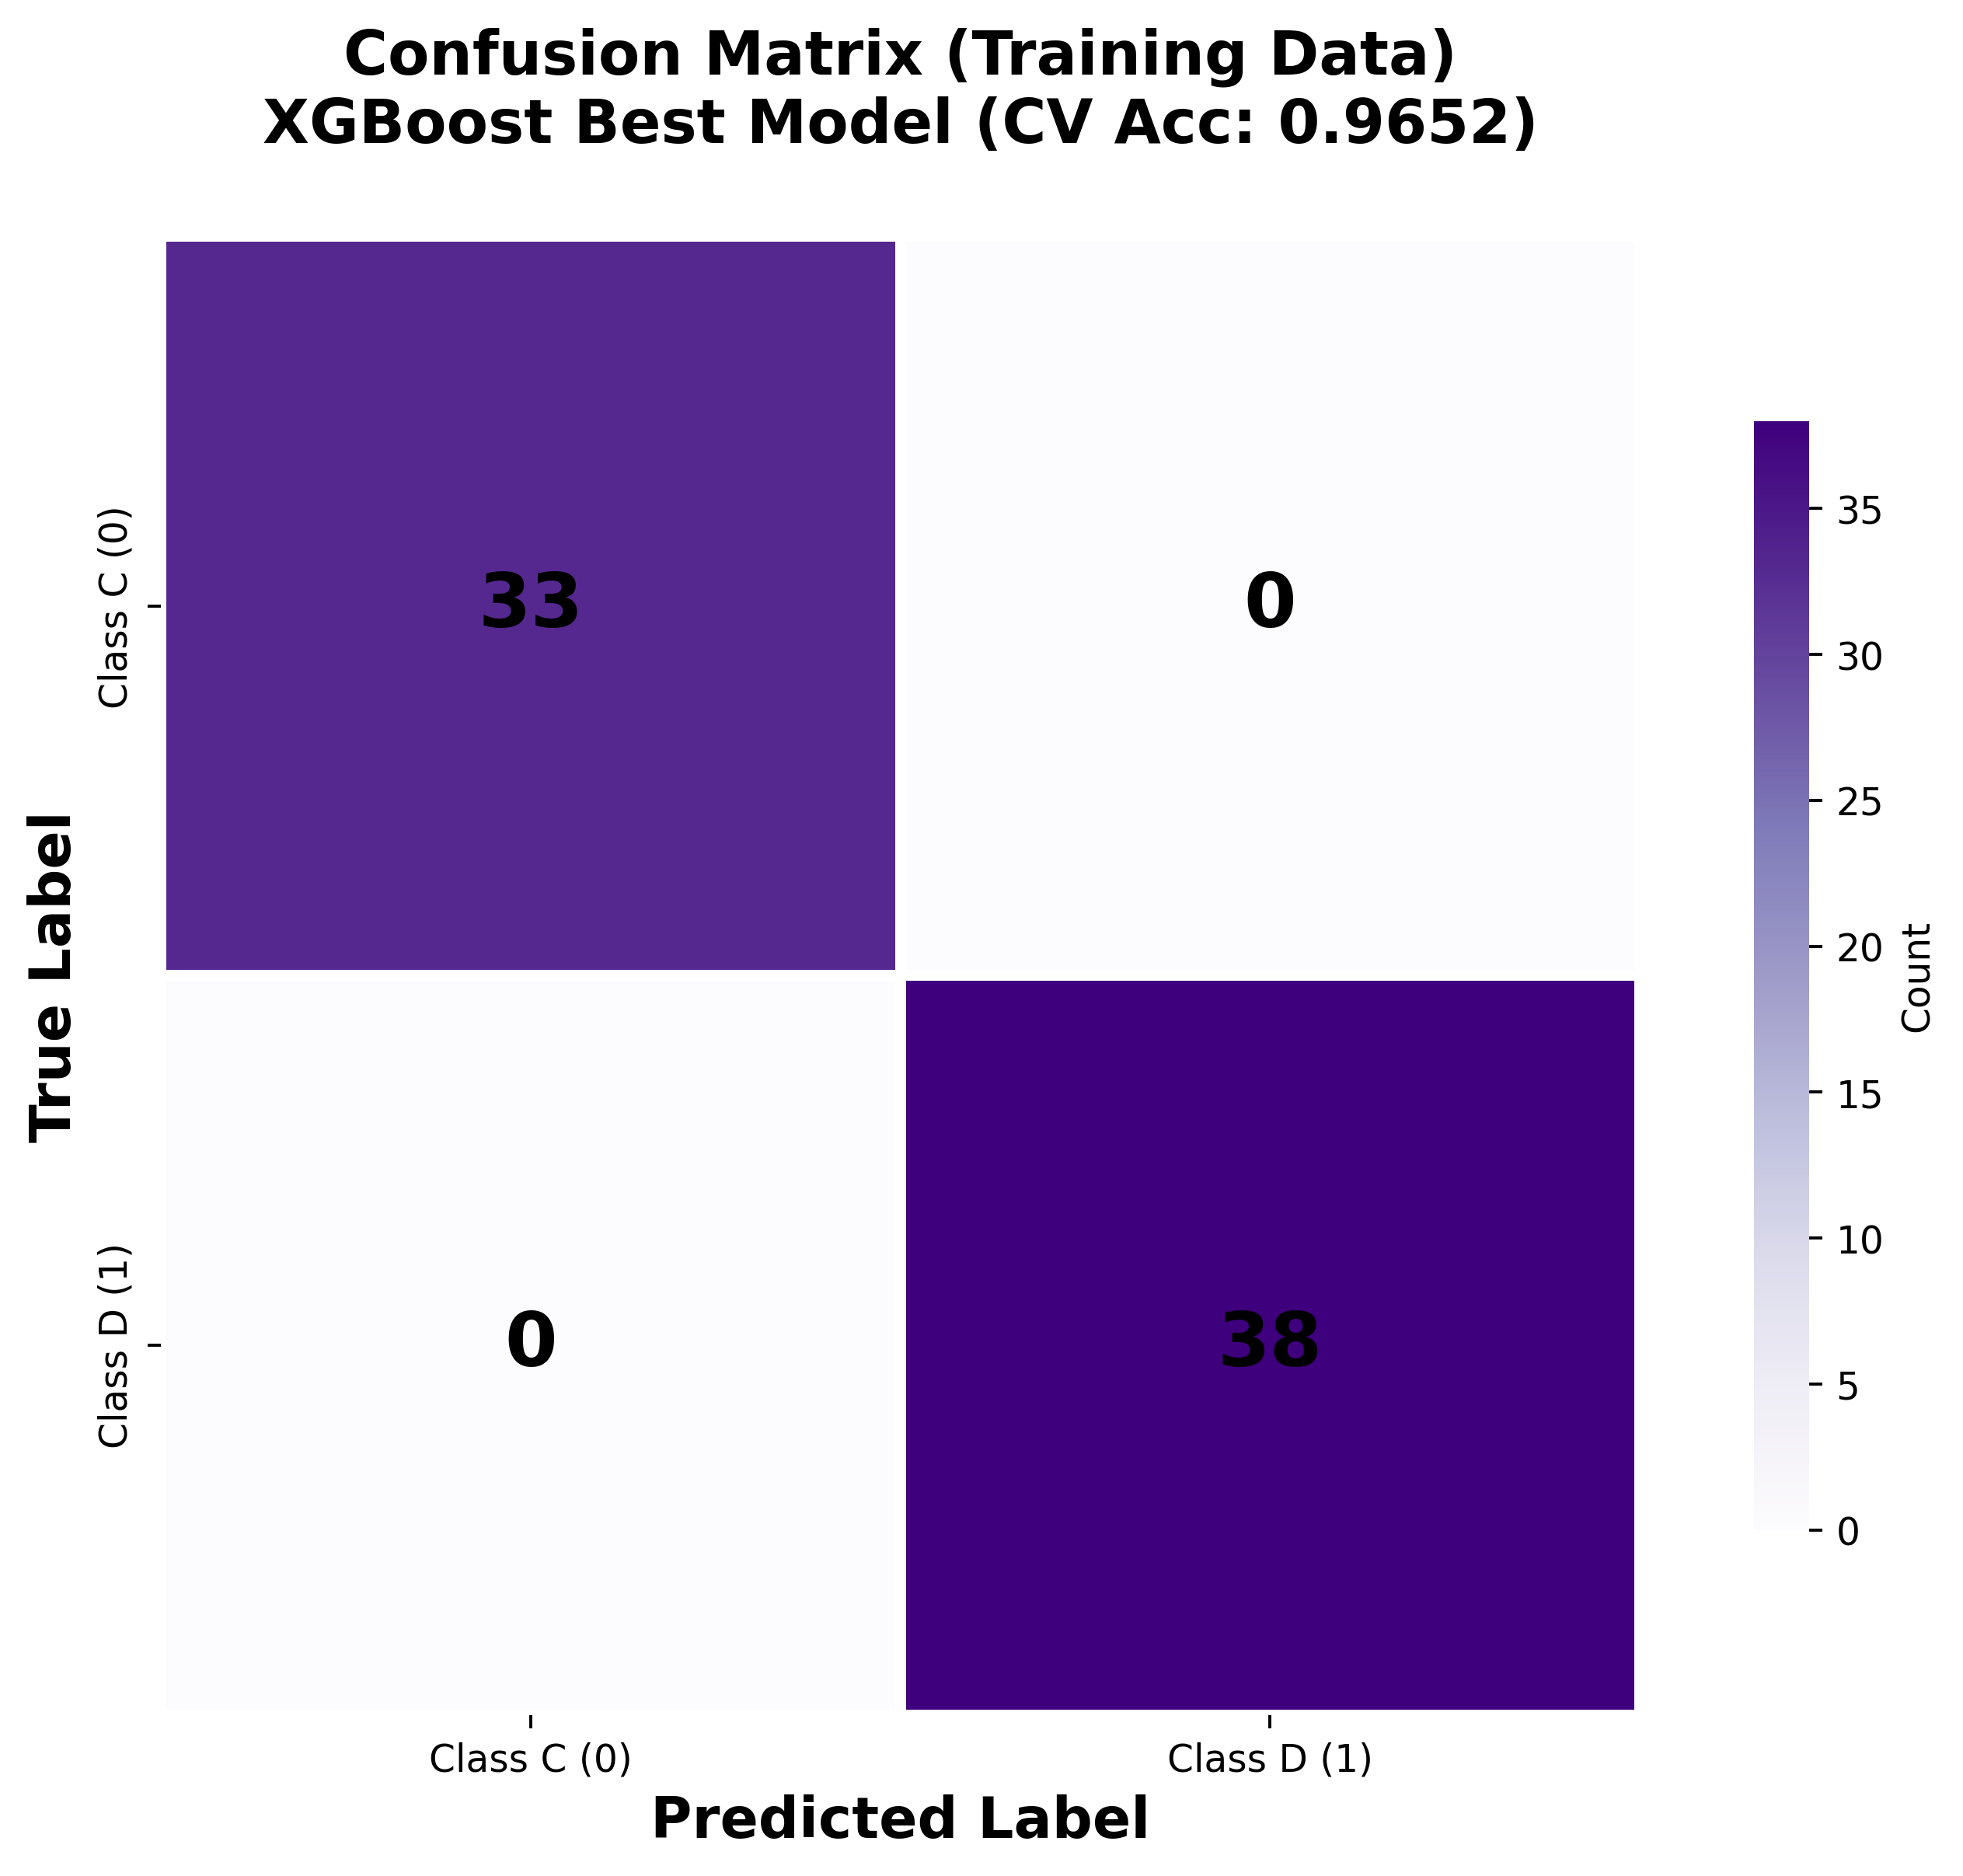

✅ Pink Confusion Matrix saved as 'confusion_matrix_best_xgboost_20260529_121327.png'

FINAL MODEL PERFORMANCE ON TRAINING DATA
Best CV Accuracy : 0.9652
Training Accuracy: 1.0000
Precision        : 1.0000
Recall           : 1.0000
F1-Score         : 1.0000
MCC              : 1.0000

CONFUSION MATRIX (Raw Counts)
                    Predicted C    Predicted D
True Class C                33             0
True Class D                 0            38


In [ ]:



# ======================================================================
#  PINK CONFUSION MATRIX - BEST CV MODEL
# ======================================================================

y_pred = best_model.predict(X)
cm = confusion_matrix(y, y_pred)

plot_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

# Plot
fig, ax = plt.subplots(figsize=(9, 7), dpi=350)

pink_colors = ['#fce4ec', '#f8bbd9', '#f48fb1', '#f06292', '#ec407a', '#e91e63']
pink_cmap = ListedColormap(pink_colors)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap="Purples",
    cbar=True,
    cbar_kws={'label': 'Count', 'shrink': 0.75},
    square=True,
    linewidths=2.5,
    linecolor='white',
    annot_kws={'size': 20, 'weight': 'bold', 'color': 'black'},
    xticklabels=['Class C (0)', 'Class D (1)'],
    yticklabels=['Class C (0)', 'Class D (1)'],
    ax=ax
)

plt.xlabel('Predicted Label', fontsize=15, fontweight='bold')
plt.ylabel('True Label', fontsize=15, fontweight='bold')
plt.title(
    f'Confusion Matrix (Training Data)\nXGBoost Best Model (CV Acc: {grid_search.best_score_:.4f})',
    fontsize=16,
    fontweight='bold',
    pad=25
)

plt.tight_layout()
plt.savefig(f'confusion_matrix_best_xgboost_{plot_timestamp}.png', dpi=350, bbox_inches='tight', facecolor='white')
plt.show()

print(f"✅ Pink Confusion Matrix saved as 'confusion_matrix_best_xgboost_{plot_timestamp}.png'")

# Metrics
accuracy = accuracy_score(y, y_pred)
precision = precision_score(y, y_pred, zero_division=0)
recall = recall_score(y, y_pred, zero_division=0)
f1 = f1_score(y, y_pred, zero_division=0)
mcc = matthews_corrcoef(y, y_pred)

print("\n" + "="*70)
print("FINAL MODEL PERFORMANCE ON TRAINING DATA")
print("="*70)
print(f"Best CV Accuracy : {grid_search.best_score_:.4f}")
print(f"Training Accuracy: {accuracy:.4f}")
print(f"Precision        : {precision:.4f}")
print(f"Recall           : {recall:.4f}")
print(f"F1-Score         : {f1:.4f}")
print(f"MCC              : {mcc:.4f}")

print("\n" + "="*70)
print("CONFUSION MATRIX (Raw Counts)")
print("="*70)
print(f"                    Predicted C    Predicted D")
print(f"True Class C        {cm[0,0]:>10d}    {cm[0,1]:>10d}")
print(f"True Class D        {cm[1,0]:>10d}    {cm[1,1]:>10d}")


Calculating SHAP values...
Array format, shape: (71, 49, 2)
⚠️  3D array (71, 49, 2) detected → extracting main effects (diagonal)
✅ Reduced to 2D: (71, 49)
Final SHAP shape : (71, 49)
X_array shape    : (71, 49)
Base value       : 0.5352


<Figure size 640x480 with 0 Axes>

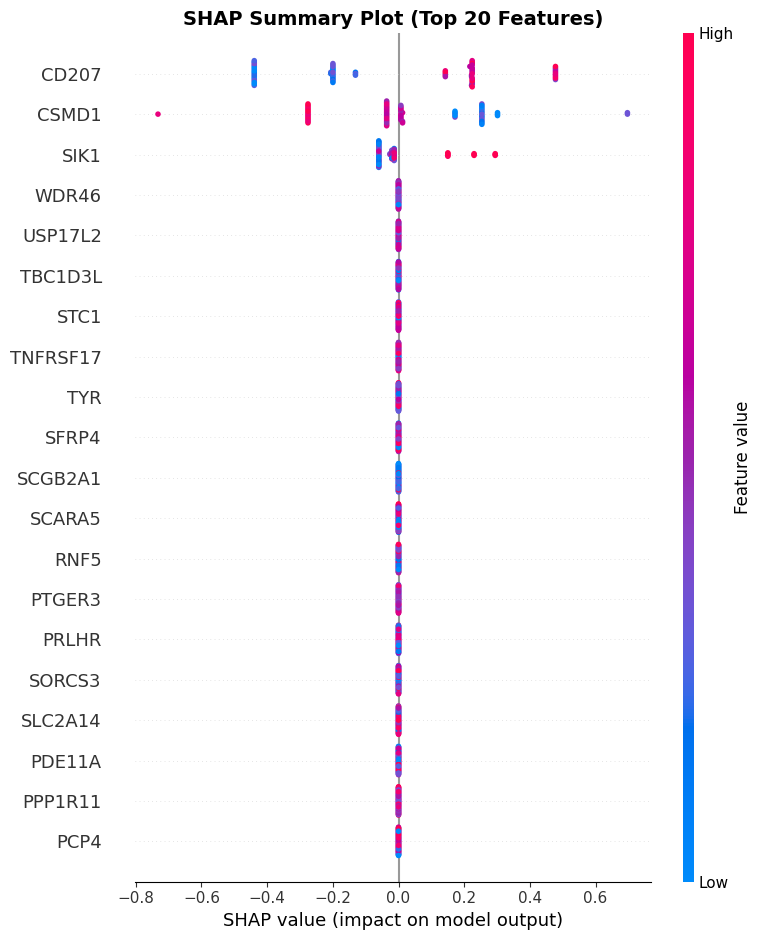

✅ Beeswarm saved


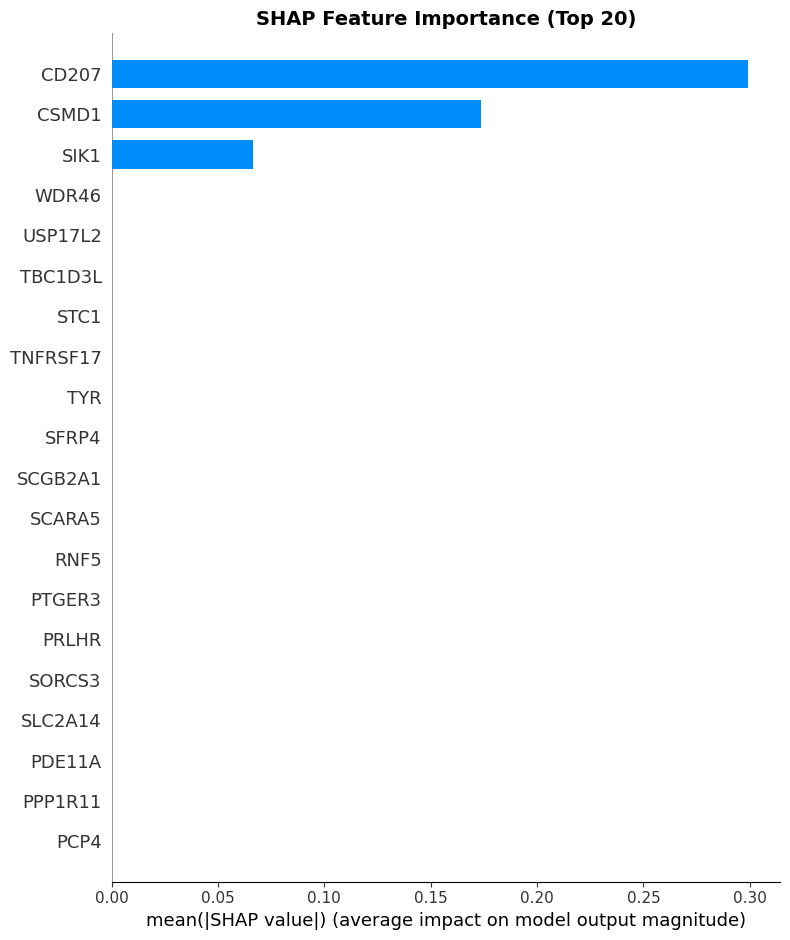

✅ Bar plot saved


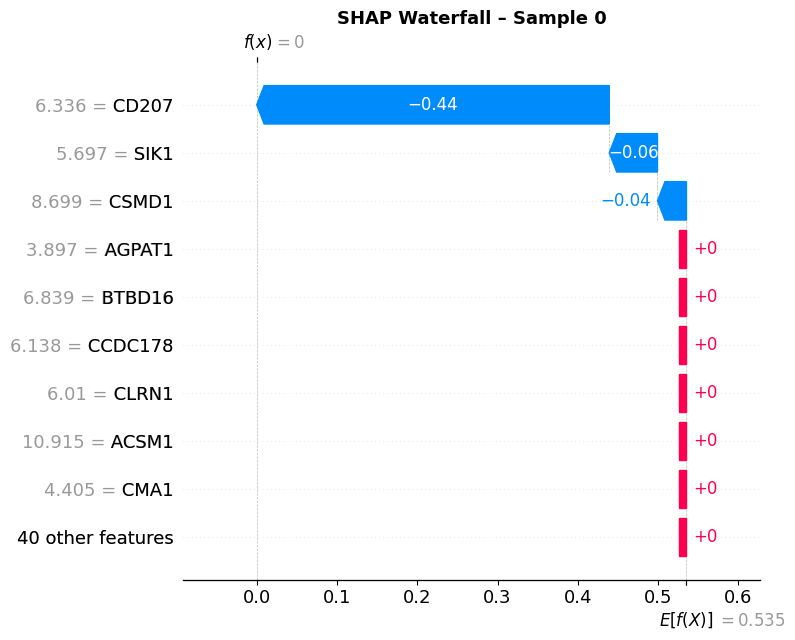

✅ Waterfall saved
✅ Importance CSV saved

Top 10 SHAP Features:
Feature  Mean_Abs_SHAP
  CD207       0.299220
  CSMD1       0.173410
   SIK1       0.066478
ADORA2B       0.000000
  ACSM1       0.000000
CCDC178       0.000000
 BTBD16       0.000000
  CLRN1       0.000000
 AGPAT1       0.000000
    DDT       0.000000


In [ ]:
v# ==========================
# 9. SHAP VALUES (FIXED)
# ==========================
import shap
import numpy as np
import pandas as pd

print("\nCalculating SHAP values...")
X_array       = X.values.astype(np.float32)
feature_names = list(X.columns)

# Force standard SHAP values — NOT interaction values
explainer = shap.TreeExplainer(best_model)
shap_values_raw = explainer.shap_values(X_array)   # DO NOT pass tree_path_dependent or interactions

# ── Robust extraction ───────────────────────────────────────────────────────
raw = np.array(shap_values_raw) if not isinstance(shap_values_raw, list) else shap_values_raw

if isinstance(raw, list):
    # list of arrays → binary classifier gives [class0, class1]
    arr = np.array(raw[1])          # positive class
    base_val = float(np.array(explainer.expected_value)[1])
    print(f"✅ List format → took index [1], shape: {arr.shape}")
else:
    arr = raw
    ev  = np.array(explainer.expected_value)
    base_val = float(ev[1]) if ev.ndim > 0 and len(ev) > 1 else float(ev.flat[0])
    print(f"Array format, shape: {arr.shape}")

# ── If still 3D, take diagonal (self-interaction = main effect) ─────────────
if arr.ndim == 3:
    print(f"⚠️  3D array {arr.shape} detected → extracting main effects (diagonal)")
    # arr shape is either (n_samples, n_features, n_features) or (n_samples, n_features, 2)
    if arr.shape[2] == arr.shape[1]:
        # True interaction matrix → diagonal gives main effects
        shap_values = np.array([np.diag(arr[i]) for i in range(arr.shape[0])])
    else:
        # (n_samples, n_features, n_classes) → take class 1
        shap_values = arr[:, :, 1]
    print(f"✅ Reduced to 2D: {shap_values.shape}")
elif arr.ndim == 2:
    shap_values = arr
    print(f"✅ Already 2D: {shap_values.shape}")
else:
    raise ValueError(f"Unexpected SHAP array shape: {arr.shape}")

print(f"Final SHAP shape : {shap_values.shape}")   # must be (n_samples, n_features)
print(f"X_array shape    : {X_array.shape}")
print(f"Base value       : {base_val:.4f}")

assert shap_values.shape == X_array.shape, \
    f"Shape mismatch — SHAP: {shap_values.shape}, X: {X_array.shape}"

# ── 9a. Beeswarm Summary ────────────────────────────────────────────────────
plot_timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

plt.figure()
shap.summary_plot(
    shap_values, X_array,
    feature_names=feature_names,
    show=False, max_display=20
)
plt.title('SHAP Summary Plot (Top 20 Features)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'shap_summary_{plot_timestamp}.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Beeswarm saved")

# ── 9b. Bar Plot ─────────────────────────────────────────────────────────────
plt.figure()
shap.summary_plot(
    shap_values, X_array,
    feature_names=feature_names,
    plot_type='bar',
    show=False, max_display=20
)
plt.title('SHAP Feature Importance (Top 20)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f'shap_bar_{plot_timestamp}.png', dpi=300, bbox_inches='tight')
plt.show()
print(f"✅ Bar plot saved")

# ── 9c. Waterfall (sample 0) — guaranteed 1D inputs ─────────────────────────
shap_exp = shap.Explanation(
    values        = shap_values[0],       # 1D (n_features,)
    base_values   = base_val,             # scalar float
    data          = X_array[0],           # 1D (n_features,)
    feature_names = feature_names
)

plt.figure()
shap.waterfall_plot(shap_exp, show=False)
plt.title('SHAP Waterfall – Sample 0', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f'shap_waterfall_{plot_timestamp}.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"✅ Waterfall saved")

# ── 9d. Importance CSV ───────────────────────────────────────────────────────
mean_shap_df = pd.DataFrame({
    'Feature'       : feature_names,
    'Mean_Abs_SHAP' : np.abs(shap_values).mean(axis=0)
}).sort_values('Mean_Abs_SHAP', ascending=False).reset_index(drop=True)

mean_shap_df.to_csv(f'shap_importance_{plot_timestamp}.csv', index=False)
print(f"✅ Importance CSV saved")
print("\nTop 10 SHAP Features:")
print(mean_shap_df.head(10).to_string(index=False))

In [1]:
import pandas as pd

In [2]:
data = pd.read_csv('/content/validation_count_matrix.csv')
data.head()

,Gene,C1,C2,C3,C4,C5,C6,C7,C8,C9,...,D11,D12,D13,D14,D15,D16,D17,D18,D19,D20
0,A1BG,115,85,98,70,146,97,97,29,58,...,88,193,153,125,108,402,249,57,183,132
1,A1BG-AS1,74,41,44,42,70,56,91,35,19,...,37,144,64,63,63,157,101,46,118,107
2,A1CF,0,3,1,8,1,0,6,0,0,...,11,1,1,13,4,0,3,3,5,1
3,A2M,35564,54680,33271,11252,44088,43126,31970,26536,12054,...,24199,30403,17418,18652,55256,37656,28001,11887,32520,25056
4,A2M-AS1,109,112,167,111,135,108,66,92,32,...,164,98,113,107,70,90,49,43,111,47


In [3]:
# ==========================
# 2. LOAD LASSO GENES
# ==========================
lasso_genes = pd.read_csv('/content/LASSO_GENES.txt')
print(f"Loaded {len(lasso_genes)} LASSO genes")

# ==========================
# 3. SELECT ONLY THESE 49 GENES FROM X_val
# ==========================


merged = pd.merge(data, lasso_genes, on="Gene", how="inner")
merged

Loaded 49 LASSO genes


,Gene,C1,C2,C3,C4,C5,C6,C7,C8,C9,...,D11,D12,D13,D14,D15,D16,D17,D18,D19,D20
0,ACSM1,339,482,225,44,62,185,124,131,34,...,109,133,53,89,311,110,104,73,41,217
1,ADORA2B,49,22,20,62,18,37,20,34,3,...,71,31,25,33,37,38,34,3,14,7
2,AGPAT1,94,4,85,31,9,102,1,79,3,...,42,139,51,1,32,183,58,25,7,129
3,BTBD16,48,18,106,40,50,79,3,63,32,...,221,30,124,197,22,19,46,16,1,15
4,CCDC178,7,5,15,24,8,7,22,4,0,...,21,5,11,15,6,9,7,13,2,3
5,CD207,12,112,25,98,222,106,55,98,40,...,14,41,11,7,8,67,21,61,25,87
6,CLRN1,168,16,13,47,20,34,9,31,6,...,21,29,8,300,5,42,19,54,2,7
7,CMA1,1,36,5,6,25,25,7,8,59,...,1,5,3,3,6,3,2,1,2,11
8,CSMD1,27,112,360,187,43,18,111,49,5,...,246,31,333,361,70,2,43,73,56,27
9,DDT,1,2,0,1,20,1,6,0,0,...,0,5,9,1,0,0,6,3,0,1


In [4]:
data = merged.T

In [5]:
import pandas as pd

In [6]:

# Labels from row index
y = data.index.to_series().str[0].map({'C': 0, 'D': 1})
y = y.drop("Gene")
y = y.values.astype(int)

# Feature matrix
data = data.reset_index(drop=True)
data.columns = data.iloc[0]
data = data.drop(data.index[0]).apply(pd.to_numeric)
X = data
y_val = y
X_val = X

In [7]:
import pickle
import joblib
best_model = joblib.load('/content/decision_tree_best_model_20260529_1213.pkl')

# Open the file in read-binary mode



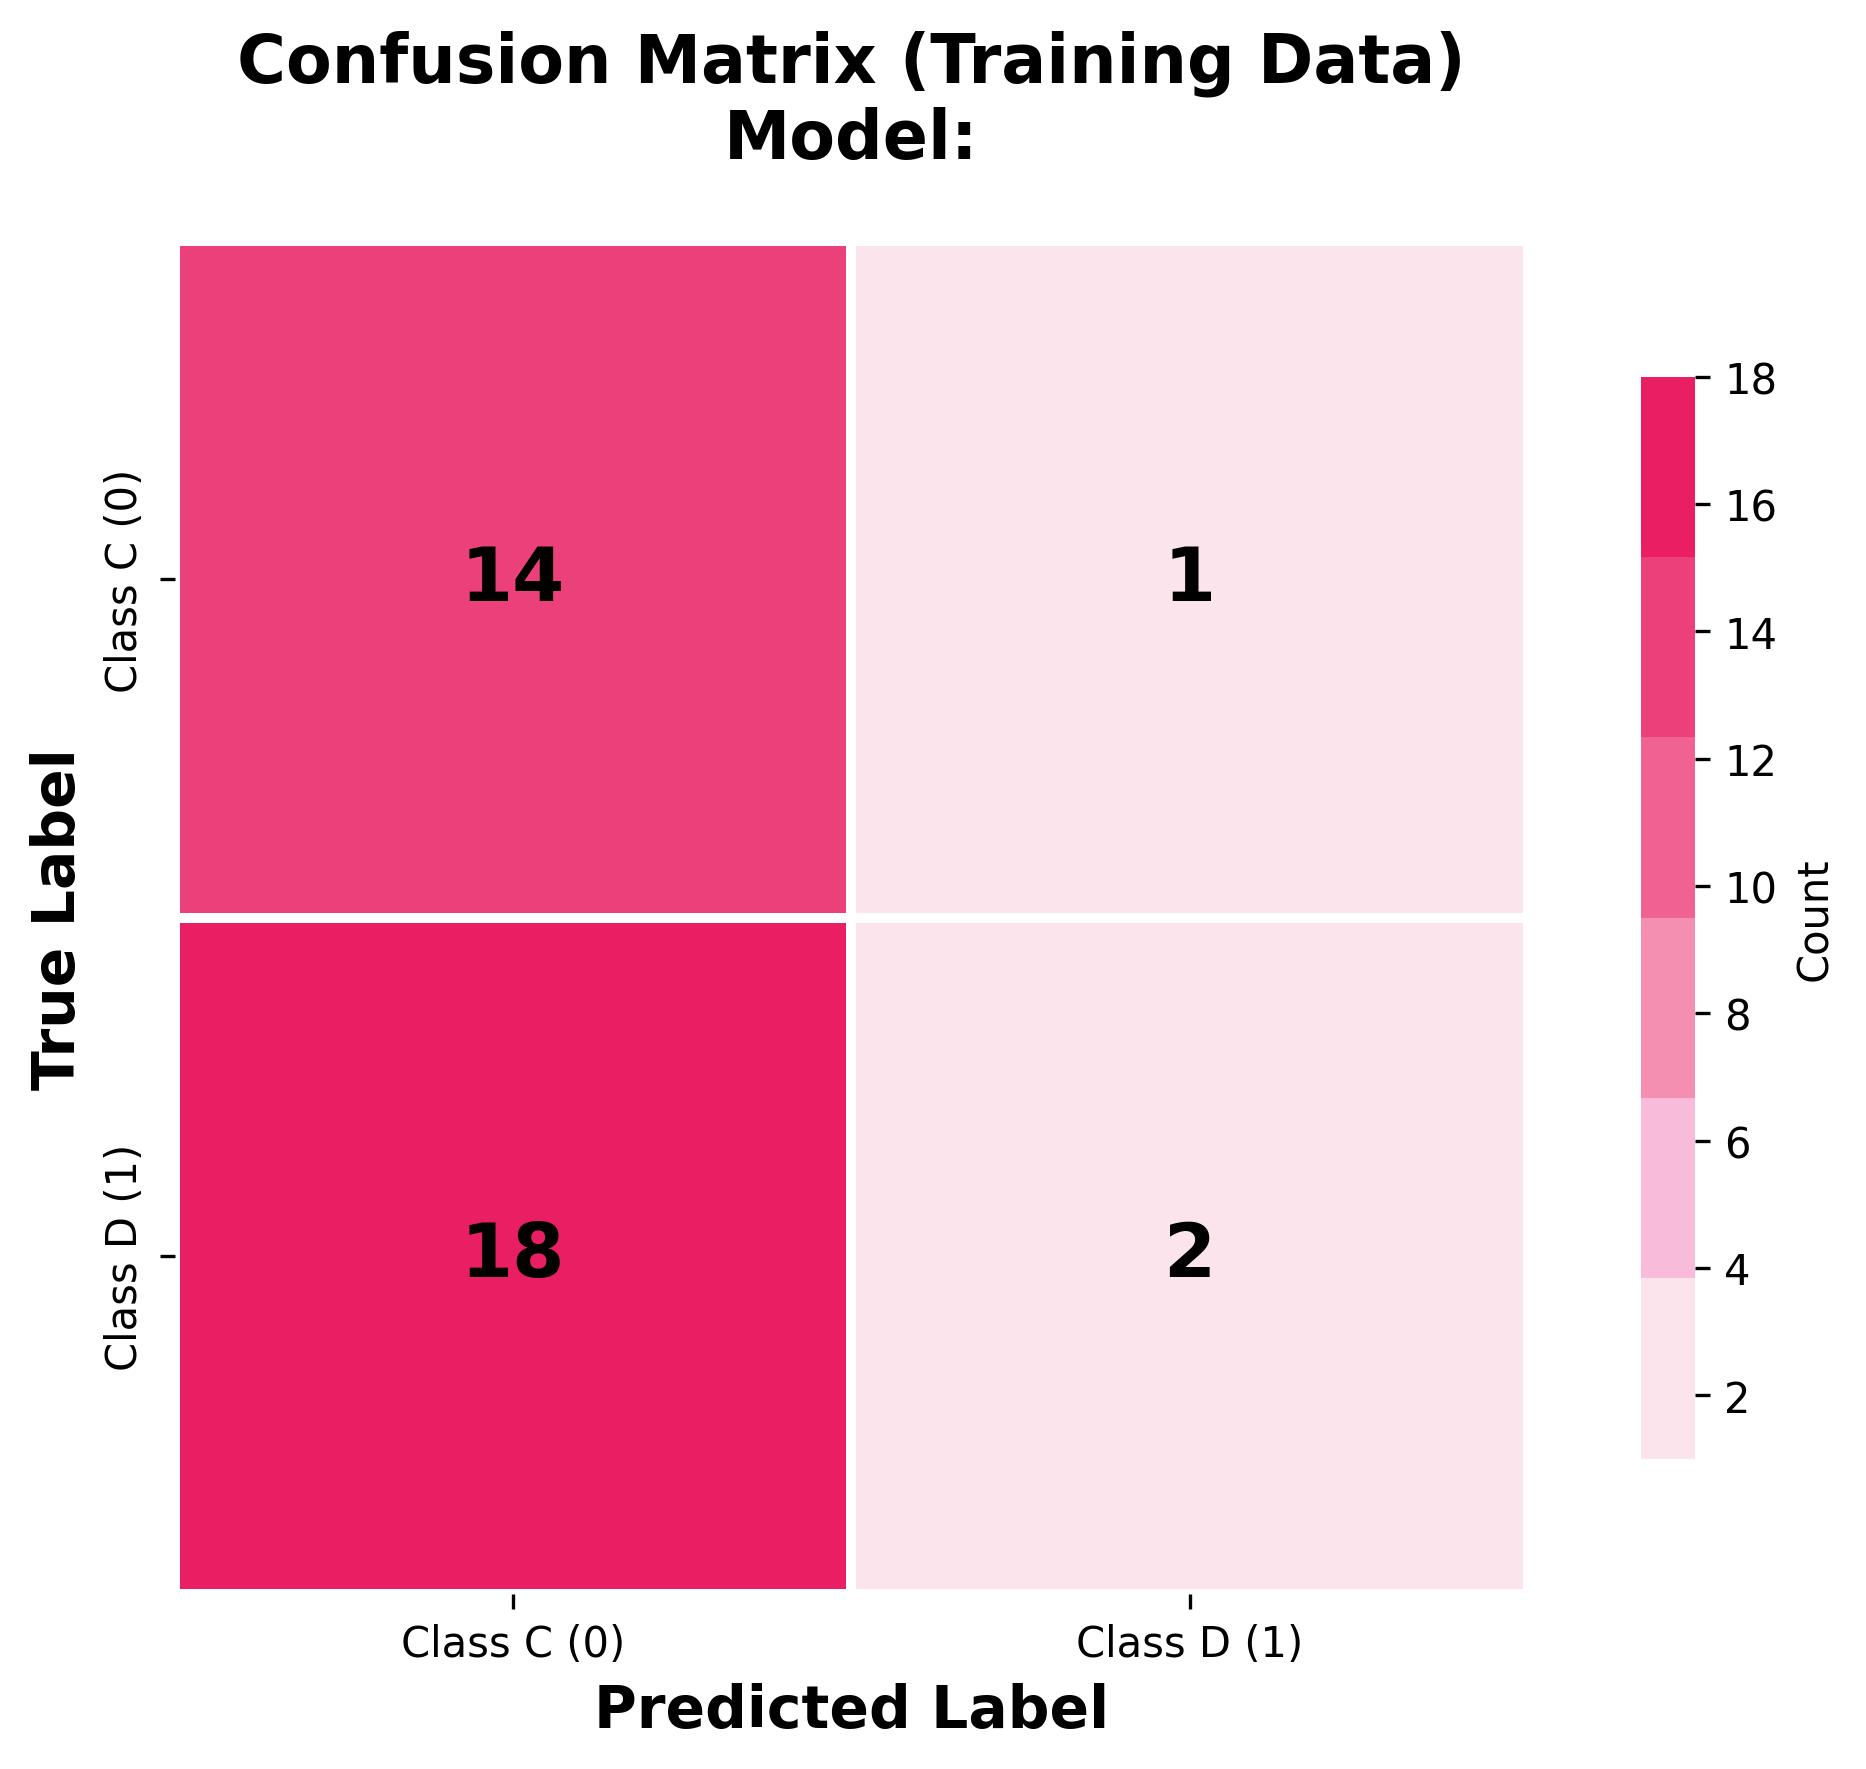


✅ Confusion matrix saved as 'confusion_matrix_.png'

MODEL PERFORMANCE METRICS
Accuracy:  0.4571
Precision: 0.6667
Recall:    0.1000
F1-Score:  0.1739
MCC:       0.0589

CONFUSION MATRIX (Raw Counts)
                    Predicted C    Predicted D
True Class C                14             1
True Class D                18             2


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
from datetime import datetime

from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score,
    recall_score, f1_score, matthews_corrcoef
)
from matplotlib.colors import ListedColormap

# ============================================================
# MAKE PREDICTIONS
# ============================================================
y_pred = best_model.predict(X_val)

# ============================================================
# COMPUTE CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_val, y_pred)

# ============================================================
# PLOT PINK CONFUSION MATRIX
# ============================================================
fig, ax = plt.subplots(figsize=(8, 6), dpi=300)

# Sweet pink colormap
pink_colors = ['#fce4ec', '#f8bbd9', '#f48fb1', '#f06292', '#ec407a', '#e91e63']
pink_cmap = ListedColormap(pink_colors)

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap=pink_cmap,
    cbar=True,
    cbar_kws={'label': 'Count', 'shrink': 0.8},
    square=True,
    linewidths=2,
    linecolor='white',
    annot_kws={'size': 18, 'weight': 'bold', 'color': 'black'},
    xticklabels=['Class C (0)', 'Class D (1)'],
    yticklabels=['Class C (0)', 'Class D (1)'],
    ax=ax
)

# Title with timestamp
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")

plt.xlabel('Predicted Label', fontsize=14, fontweight='bold')
plt.ylabel('True Label', fontsize=14, fontweight='bold')
plt.title(
    f'Confusion Matrix (Training Data)\nModel:',
    fontsize=16,
    fontweight='bold',
    pad=20
)

plt.tight_layout()
plt.savefig(
    f'confusion_matrix_{timestamp}.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()

print(f"\n✅ Confusion matrix saved as 'confusion_matrix_.png'")

# ============================================================
# PRINT METRICS
# ============================================================
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred, zero_division=0)
recall = recall_score(y_val, y_pred, zero_division=0)
f1 = f1_score(y_val, y_pred, zero_division=0)
mcc = matthews_corrcoef(y_val, y_pred)

print("\n" + "="*60)
print("MODEL PERFORMANCE METRICS")
print("="*60)
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-Score:  {f1:.4f}")
print(f"MCC:       {mcc:.4f}")

print("\n" + "="*60)
print("CONFUSION MATRIX (Raw Counts)")
print("="*60)
print(f"                    Predicted C    Predicted D")
print(f"True Class C        {cm[0,0]:>10d}    {cm[0,1]:>10d}")
print(f"True Class D        {cm[1,0]:>10d}    {cm[1,1]:>10d}")

In [9]:
import joblib
import pandas as pd
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, matthews_corrcoef,
    classification_report, confusion_matrix
)
from datetime import datetime


# ==========================
# 2. PREPARE VALIDATION DATA (Using all columns - as per your current code)
# ==========================
# Convert to numpy (required for XGBoost)
X_val_array = X_val.values.astype(np.float32)

print(f"Using validation data shape: {X_val_array.shape}")

# ==========================
# 3. PREDICTIONS
# ==========================
y_pred = best_model.predict(X_val_array)
y_pred_proba = best_model.predict_proba(X_val_array)[:, 1]

# ==========================
# 4. CALCULATE ALL METRICS + AUCPRC
# ==========================
metrics = {
    'Accuracy': accuracy_score(y_val, y_pred),
    'ROC-AUC': roc_auc_score(y_val, y_pred_proba),
    'AUCPRC': average_precision_score(y_val, y_pred_proba),   # ← Added AUCPRC
    'Avg Precision': average_precision_score(y_val, y_pred_proba),
    'F1 Score': f1_score(y_val, y_pred),
    'F1 Macro': f1_score(y_val, y_pred, average='macro'),
    'F1 Weighted': f1_score(y_val, y_pred, average='weighted'),
    'Precision': precision_score(y_val, y_pred, zero_division=0),
    'Recall': recall_score(y_val, y_pred, zero_division=0),
    'MCC': matthews_corrcoef(y_val, y_pred),
}

print("\n" + "="*75)
print("📊 VALIDATION SET PERFORMANCE (LASSO 49 Genes)")
print("="*75)

for k, v in metrics.items():
    print(f"{k:20} : {v:.4f}")

print("\n" + "="*75)
print("CLASSIFICATION REPORT")
print("="*75)
print(classification_report(y_val, y_pred, digits=4))

# Save results
timestamp = datetime.now().strftime("%Y%m%d_%H%M")
pd.DataFrame([metrics]).to_csv(f'validation_metrics_{timestamp}.csv', index=False)
print(f"\n✅ Metrics saved as 'validation_metrics_{timestamp}.csv'")

Using validation data shape: (35, 49)

📊 VALIDATION SET PERFORMANCE (LASSO 49 Genes)
Accuracy             : 0.4571
ROC-AUC              : 0.5167
AUCPRC               : 0.5810
Avg Precision        : 0.5810
F1 Score             : 0.1739
F1 Macro             : 0.3848
F1 Weighted          : 0.3547
Precision            : 0.6667
Recall               : 0.1000
MCC                  : 0.0589

CLASSIFICATION REPORT
              precision    recall  f1-score   support

           0     0.4375    0.9333    0.5957        15
           1     0.6667    0.1000    0.1739        20

    accuracy                         0.4571        35
   macro avg     0.5521    0.5167    0.3848        35
weighted avg     0.5685    0.4571    0.3547        35


✅ Metrics saved as 'validation_metrics_20260624_0525.csv'


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [10]:
from sklearn.metrics import roc_curve
from sklearn.metrics import precision_recall_curve


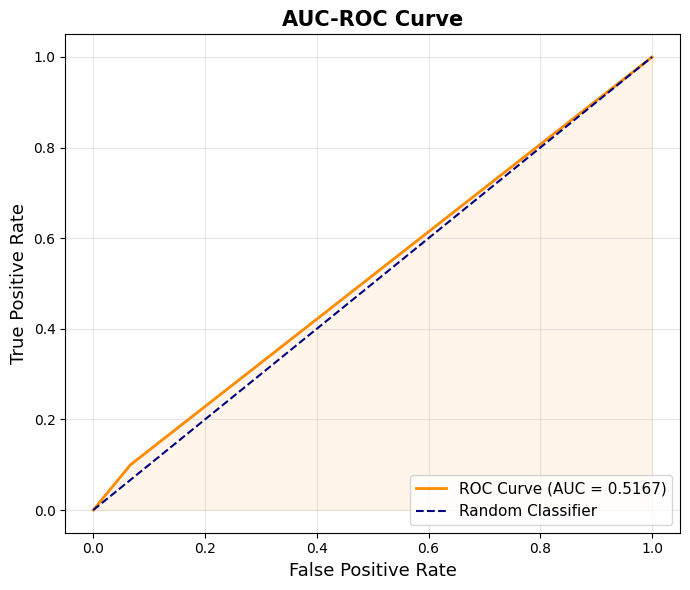

✅ AUC-ROC curve saved as 'aucroc_curve.png'


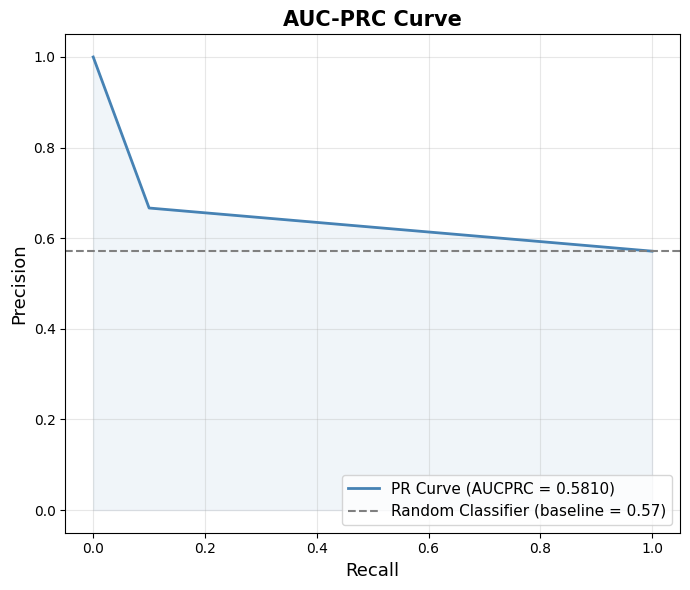

✅ AUC-PRC curve saved as 'aucprc_curve.png'


In [11]:

# ==========================
# 5. AUC-ROC CURVE
# ==========================
fpr, tpr, _ = roc_curve(y_val, y_pred_proba)
roc_auc     = metrics['ROC-AUC']

plt.figure(figsize=(7, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2,
         label=f'ROC Curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=1.5, linestyle='--', label='Random Classifier')
plt.fill_between(fpr, tpr, alpha=0.08, color='darkorange')
plt.xlabel('False Positive Rate', fontsize=13)
plt.ylabel('True Positive Rate', fontsize=13)
plt.title('AUC-ROC Curve', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('aucroc_curve.png', dpi=150)
plt.show()
print("✅ AUC-ROC curve saved as 'aucroc_curve.png'")

# ==========================
# 6. AUC-PRC CURVE
# ==========================
precision_vals, recall_vals, _ = precision_recall_curve(y_val, y_pred_proba)
aucprc   = metrics['AUCPRC']
baseline = np.sum(y_val) / len(y_val)

plt.figure(figsize=(7, 6))
plt.plot(recall_vals, precision_vals, color='steelblue', lw=2,
         label=f'PR Curve (AUCPRC = {aucprc:.4f})')
plt.axhline(y=baseline, color='gray', lw=1.5, linestyle='--',
            label=f'Random Classifier (baseline = {baseline:.2f})')
plt.fill_between(recall_vals, precision_vals, alpha=0.08, color='steelblue')
plt.xlabel('Recall', fontsize=13)
plt.ylabel('Precision', fontsize=13)
plt.title('AUC-PRC Curve', fontsize=15, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('aucprc_curve.png', dpi=150)
plt.show()
print("✅ AUC-PRC curve saved as 'aucprc_curve.png'")

